# QAOA Example (MaxCut)

这里展示如何使用 `cqlib-algorithm` 中的 QAOA 求解 MaxCut 问题。

In [27]:
from cqlib_algorithm.problems.maxcut import MaxCut
from cqlib_algorithm.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_algorithm.visualization.maxcut_plot import plot_maxcut
from cqlib_algorithm.execution import LocalRunner
from cqlib_algorithm.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_algorithm.optimizers.options import OptimizerOptions
print('Imports ready')

Imports ready


## 1. 定义 MaxCut 实例

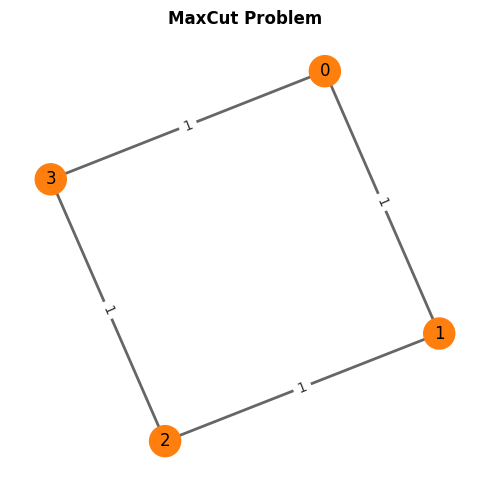

In [28]:
weights =  {(0,1):1, (1,2):1, (2,3):1, (3,0):1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title='MaxCut Problem')

## 2. Maxcut → QUBO

In [29]:
qubo  = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Q = [
 [0.000, -2.000, 0.000, -2.000]
 [-2.000, 0.000, -2.000, 0.000]
 [0.000, -2.000, 0.000, -2.000]
 [-2.000, 0.000, -2.000, 0.000]
]
c = [2.000, 2.000, 2.000, 2.000]
offset = 0.000



## 3. QUBO → Ising

In [30]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. 运行 QAOA（LocalRunner）

[iter=  1] f=0.892 theta=[0.927, 0.927, 0.927, 0.327, 0.073, 0.073]
[iter=  2] f=0.082 theta=[1.111, 1.111, 0.743, 0.143, 0.257, 0.257]
[iter=  3] f=0.318 theta=[1.228, 1.228, 0.861, 0.026, 0.374, 0.374]
[iter=  4] f=0.140 theta=[1.322, 1.135, 0.954, 0.119, 0.468, 0.281]
[iter=  5] f=-0.686 theta=[1.457, 1.270, 1.089, 0.254, 0.333, 0.416]
[iter=  6] f=-1.816 theta=[1.736, 1.549, 0.810, 0.533, 0.054, 0.695]
[iter=  7] f=-0.854 theta=[1.942, 1.755, 0.604, 0.327, -0.153, 0.489]
[iter=  8] f=-0.854 theta=[2.072, 1.885, 0.474, 0.197, -0.023, 0.618]
[iter=  9] f=-0.958 theta=[1.965, 1.779, 0.580, 0.303, -0.129, 0.512]
[iter= 10] f=-0.950 theta=[2.049, 1.862, 0.497, 0.220, -0.046, 0.596]
[iter= 11] f=-1.424 theta=[2.208, 2.022, 0.337, 0.379, 0.114, 0.436]
[iter= 12] f=-1.506 theta=[2.195, 2.008, 0.324, 0.393, 0.127, 0.450]
[iter= 13] f=-1.402 theta=[2.402, 1.802, 0.117, 0.599, -0.079, 0.243]
[iter= 14] f=-1.422 theta=[2.374, 1.774, 0.089, 0.572, -0.107, 0.271]
[iter= 15] f=-1.766 theta=[2.442

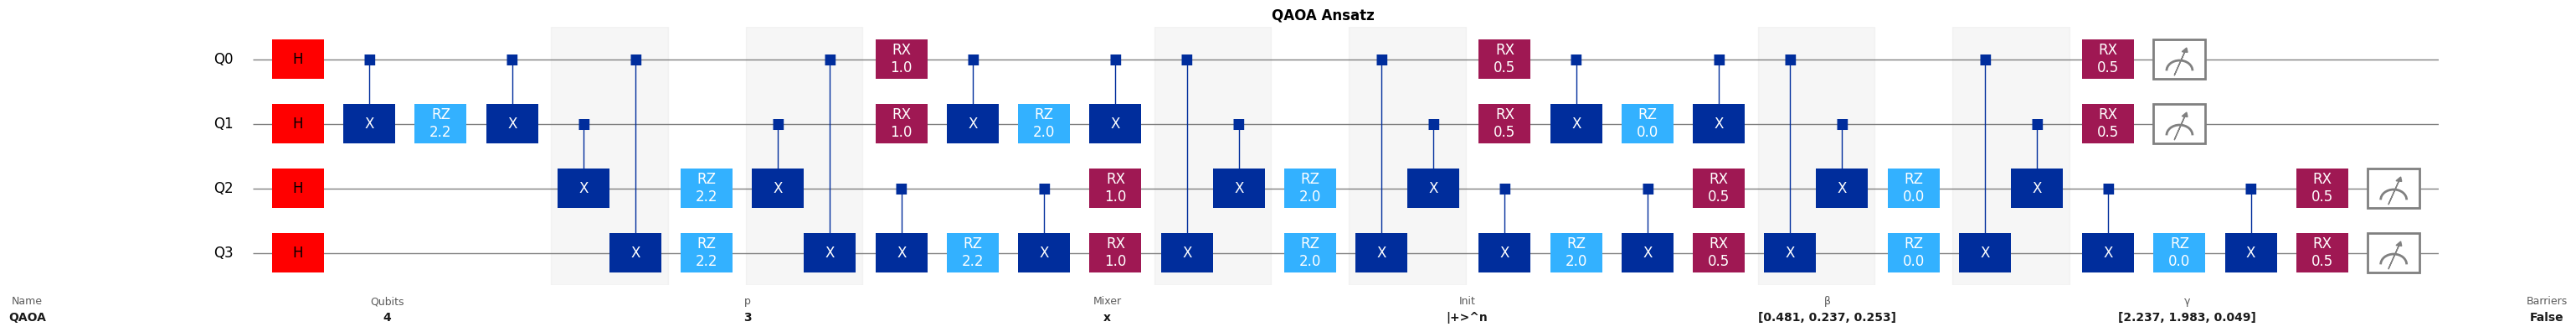

In [31]:
opt_cfg = OptimizerOptions(name="spsa", options={"maxiter": 50, "a": 0.2, "c": 0.2})
solver = QAOASolver(ising, 
                    runner=LocalRunner(), 
                    qaoa_cfg=QAOAConfig(reps=3, mixer="x"), 
                    opt_cfg=opt_cfg)
res = solver.run()

## 5. 可视化：运行结果

In [32]:
res.print_result()


========== [ Experiment Information ] ==========
任务ID     : 20250926162702
shots 数量 : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'spsa', 'options': {'maxiter': 50, 'a': 0.2, 'c': 0.2}}

========== [ Measurement Results ] ==========
probability : {'0101': 0.504, '1010': 0.454, '1100': 0.013, '0110': 0.01, '1001': 0.008, '0011': 0.005, '1110': 0.002, '0000': 0.001, '0010': 0.001, '0100': 0.001, '1000': 0.001}


## 6. 可视化：迭代曲线与概率分布

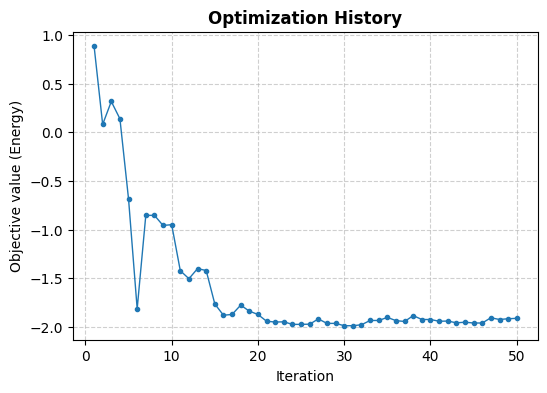

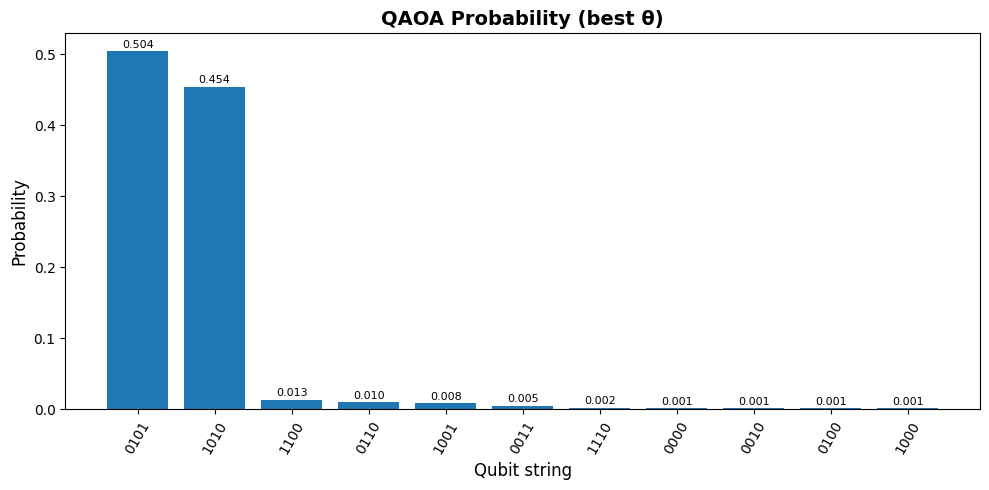

In [33]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. 可视化：最优 MaxCut 解


========== [ Optimization Results ] ==========
Best gammas : [2.237, 1.983, 0.049]
Best betas  : [0.481, 0.237, 0.253]
Best energy : -1.914
Best Qubit string:  0101
Best solution: [1, 3]
Max-Cut value: 4.000


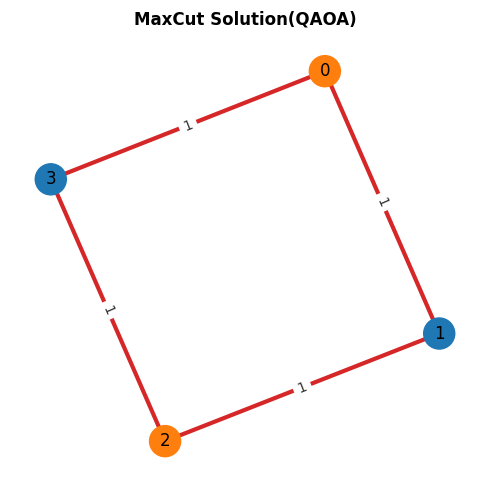

[1, 3]

In [34]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### 可选：对接中电信“天衍”量子计算云平台后端
将 `LocalRunner()` 替换为 `TianYanRunner()`：
```python
from cqlib_algorithm.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
